# EDA: DataCollectionAgent

Анализ данных, собранных агентом из нескольких источников.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

df = pd.read_csv('../data/raw/dataset.csv')
print(f"Shape: {df.shape}")
print(f"\nDtypes:\n{df.dtypes}")
print(f"\nNull values:\n{df.isnull().sum()}")
df.head(10)


Shape: (1010, 4)

Dtypes:
text            object
label           object
source          object
collected_at    object
dtype: object

Null values:
text            0
label           0
source          0
collected_at    0
dtype: int64


,text,label,source,collected_at
0,There is no relation at all between Fortier an...,positive,hf_imdb,2026-03-17 18:52:15.794700+00:00
1,This movie is a great. The plot is very true t...,positive,hf_imdb,2026-03-17 18:52:15.794700+00:00
2,"George P. Cosmatos' ""Rambo: First Blood Part I...",negative,hf_imdb,2026-03-17 18:52:15.794700+00:00
3,In the process of trying to establish the audi...,positive,hf_imdb,2026-03-17 18:52:15.794700+00:00
4,"Yeh, I know -- you're quivering with excitemen...",negative,hf_imdb,2026-03-17 18:52:15.794700+00:00
5,While this movie's style isn't as understated ...,positive,hf_imdb,2026-03-17 18:52:15.794700+00:00
6,I give this movie 7 out of 10 because the vill...,positive,hf_imdb,2026-03-17 18:52:15.794700+00:00
7,"really awful... lead actor did OK... the film,...",negative,hf_imdb,2026-03-17 18:52:15.794700+00:00
8,Good grief I can't even begin to describe how ...,negative,hf_imdb,2026-03-17 18:52:15.794700+00:00
9,Home Room deals with a Columbine-like high-sch...,positive,hf_imdb,2026-03-17 18:52:15.794700+00:00


## Распределение по источникам

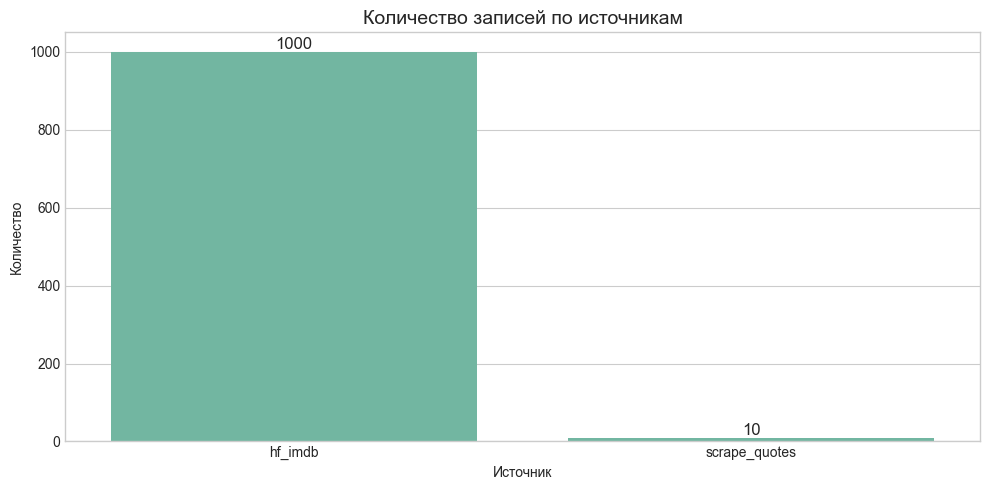

In [2]:
fig, ax = plt.subplots(figsize=(10, 5))
counts = df['source'].value_counts()
bars = sns.countplot(data=df, x='source', ax=ax)
ax.set_title('Количество записей по источникам', fontsize=14)
ax.set_xlabel('Источник')
ax.set_ylabel('Количество')
for bar in bars.patches:
    bars.annotate(f'{int(bar.get_height())}',
                  (bar.get_x() + bar.get_width() / 2., bar.get_height()),
                  ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()


## Распределение классов

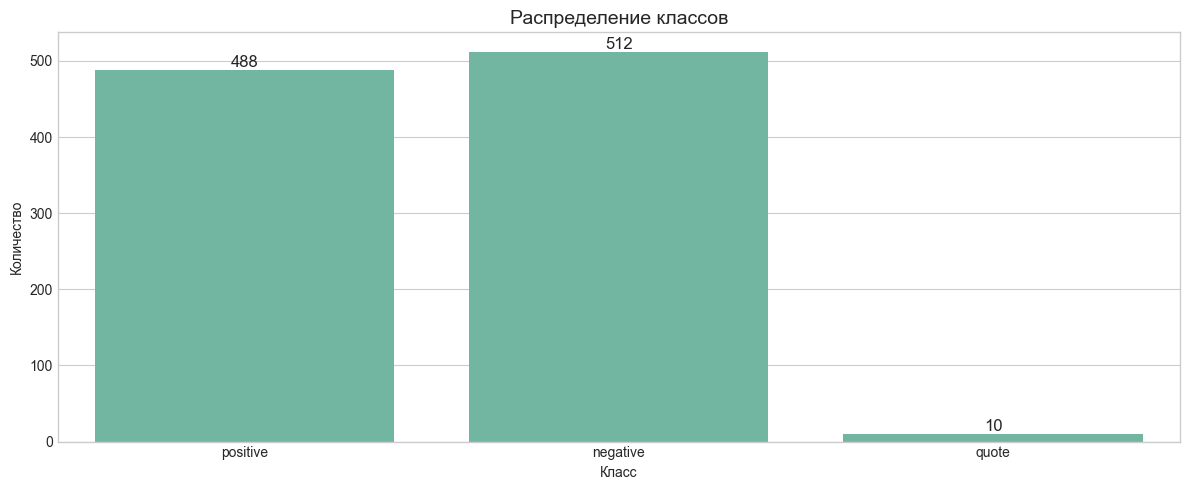

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))
bars = sns.countplot(data=df, x='label', ax=ax)
ax.set_title('Распределение классов', fontsize=14)
ax.set_xlabel('Класс')
ax.set_ylabel('Количество')
for bar in bars.patches:
    bars.annotate(f'{int(bar.get_height())}',
                  (bar.get_x() + bar.get_width() / 2., bar.get_height()),
                  ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()


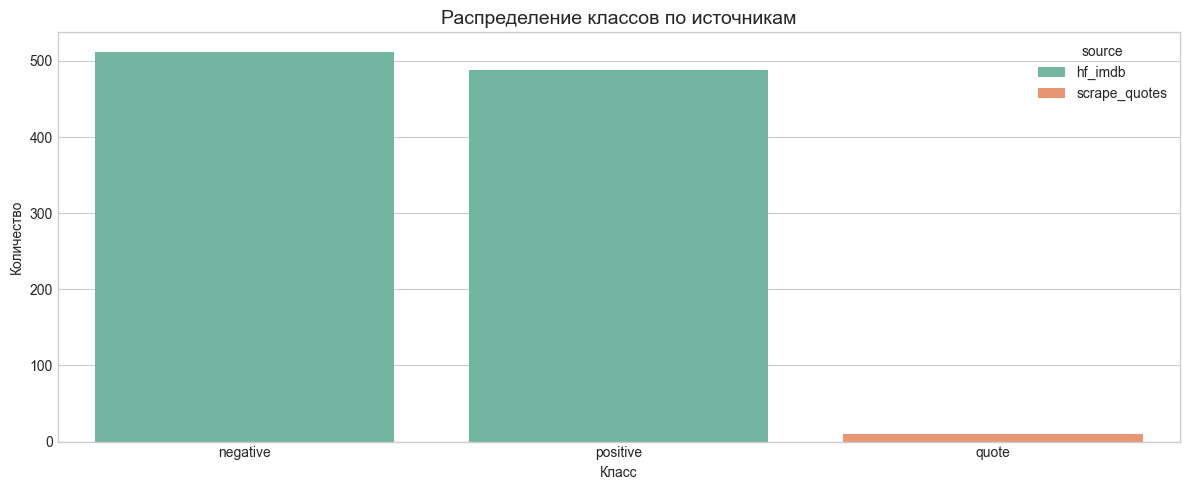

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
ct = df.groupby(['source', 'label']).size().reset_index(name='count')
sns.barplot(data=ct, x='label', y='count', hue='source', ax=ax)
ax.set_title('Распределение классов по источникам', fontsize=14)
ax.set_xlabel('Класс')
ax.set_ylabel('Количество')
plt.tight_layout()
plt.show()


## Распределение длин текстов

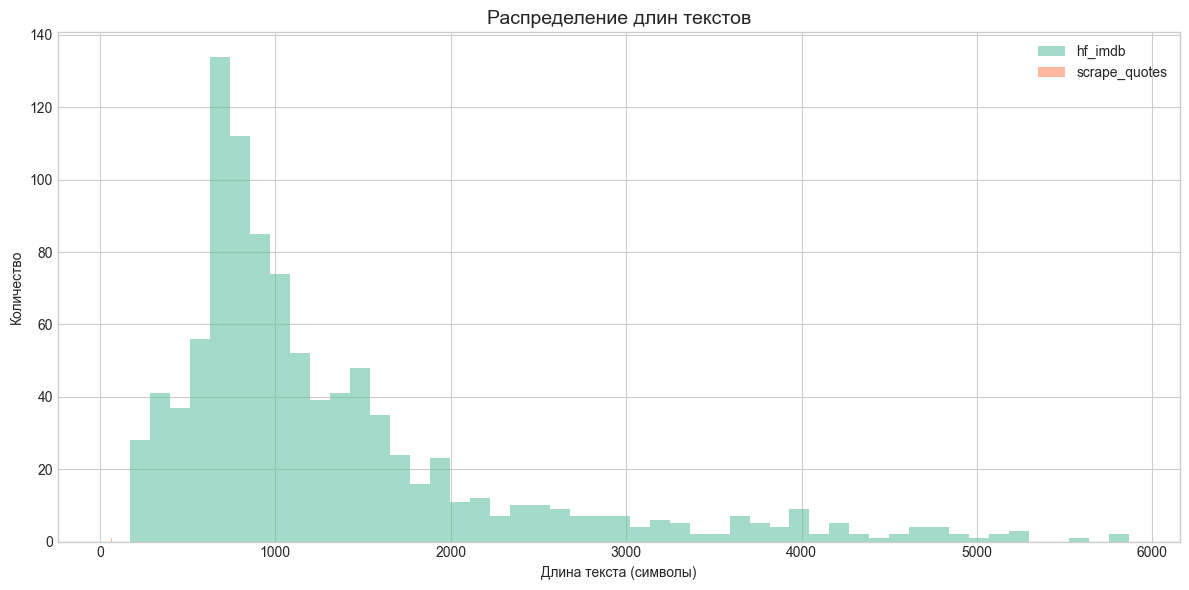

Статистика длин текстов по источникам:


,mean,median,min,max
source,,,,
hf_imdb,1313.3,986.0,174.0,5867.0
scrape_quotes,89.5,85.0,50.0,131.0


In [5]:
df['text_length'] = df['text'].str.len()

fig, ax = plt.subplots(figsize=(12, 6))
for src in df['source'].unique():
    subset = df[df['source'] == src]
    ax.hist(subset['text_length'], bins=50, alpha=0.6, label=src)
ax.set_title('Распределение длин текстов', fontsize=14)
ax.set_xlabel('Длина текста (символы)')
ax.set_ylabel('Количество')
ax.legend()
plt.tight_layout()
plt.show()

print("Статистика длин текстов по источникам:")
df.groupby('source')['text_length'].describe()[['mean', '50%', 'min', 'max']].rename(
    columns={'50%': 'median'}).round(1)


## Топ-20 слов (без стоп-слов)

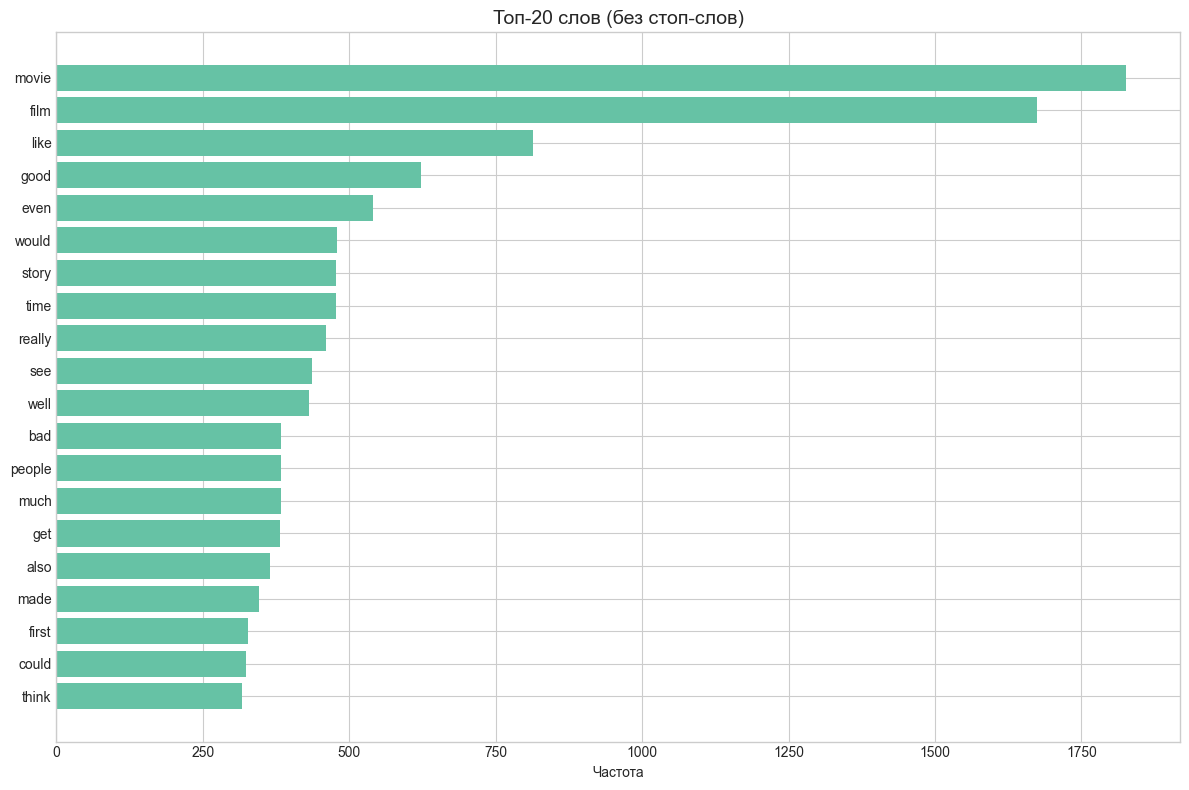

In [6]:
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))
stop_words.update(['the', 'and', 'for', 'that', 'this', 'with', 'are', 'was', 'but', 'not',
                   'you', 'all', 'can', 'had', 'her', 'one', 'our', 'out', 'has', 'have',
                   'его', 'она', 'они', 'это', 'как', 'что', 'для', 'при', 'все', 'так'])

all_words = []
for text in df['text'].dropna():
    words = re.findall(r'\b[a-zA-Za-яА-ЯёЁ]{3,}\b', text.lower())
    all_words.extend([w for w in words if w not in stop_words])

word_counts = Counter(all_words).most_common(20)

fig, ax = plt.subplots(figsize=(12, 8))
words, counts = zip(*word_counts)
ax.barh(range(len(words)), counts)
ax.set_yticks(range(len(words)))
ax.set_yticklabels(words)
ax.invert_yaxis()
ax.set_title('Топ-20 слов (без стоп-слов)', fontsize=14)
ax.set_xlabel('Частота')
plt.tight_layout()
plt.show()


## Word Cloud

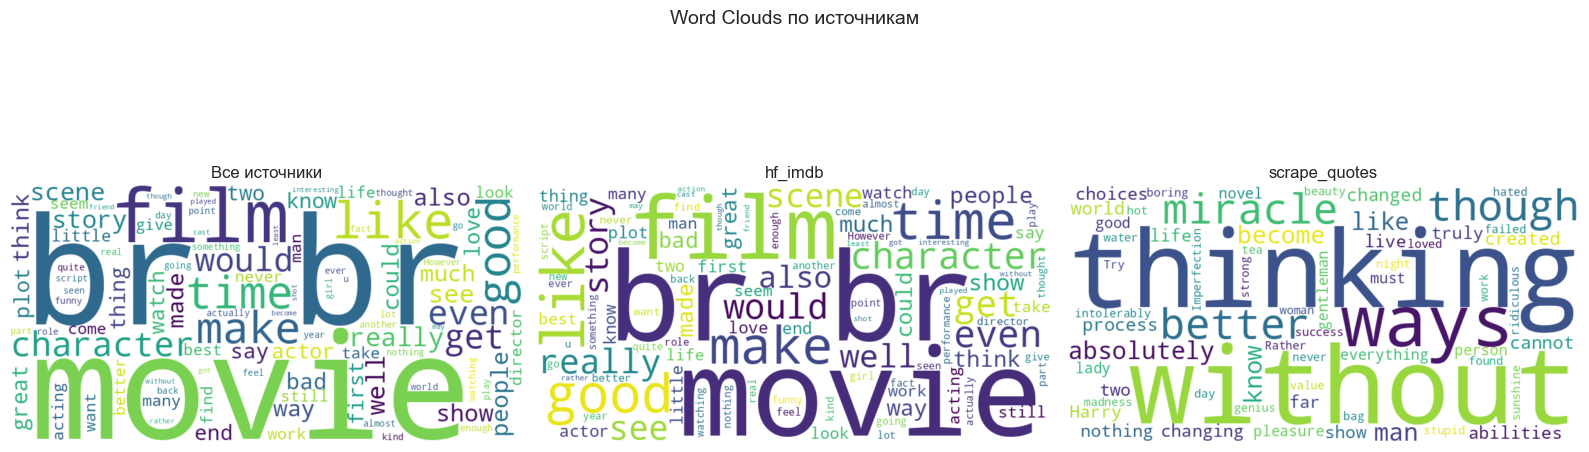

In [7]:
from wordcloud import WordCloud

all_text = ' '.join(df['text'].dropna())
wc = WordCloud(width=800, height=400, background_color='white',
               stopwords=stop_words, max_words=100).generate(all_text)

sources = df['source'].unique()
fig, axes = plt.subplots(1, len(sources) + 1, figsize=(16, 6))

axes[0].imshow(wc, interpolation='bilinear')
axes[0].set_title('Все источники', fontsize=12)
axes[0].axis('off')

for i, src in enumerate(sources):
    src_text = ' '.join(df[df['source'] == src]['text'].dropna())
    src_wc = WordCloud(width=800, height=400, background_color='white',
                       stopwords=stop_words, max_words=100).generate(src_text)
    axes[i + 1].imshow(src_wc, interpolation='bilinear')
    axes[i + 1].set_title(src, fontsize=12)
    axes[i + 1].axis('off')

plt.suptitle('Word Clouds по источникам', fontsize=14)
plt.tight_layout()
plt.show()


## Выводы

- **Общее количество записей:** определяется при выполнении ноутбука
- **Количество источников:** 2 (HuggingFace imdb, web scraping quotes.toscrape.com)
- **Баланс классов:** positive/negative примерно сбалансированы (imdb), quote — малый класс (scraping)
- **Средняя длина текста:** отзывы imdb значительно длиннее цитат с quotes.toscrape.com
- **Особенности:** данные из разных источников имеют принципиально разную природу текстов и длину
